In [23]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
from typing import Pattern

from utils import *

# Parser
POC_DIR = Path("/Users/hyeon/SeSAC_Project/PoC")    # PoC의 절대경로 입력
RUN_FOLDER = "test7"
RUN_DIR = POC_DIR / "run" / RUN_FOLDER

# 루트 디렉토리 바로 아래의 pose_predictions.json 지정
OUTPUTS_DIR = RUN_DIR / "outputs"

user = RUN_DIR / "user_info.json"
with user.open(mode="r", encoding='utf-8') as file:
    user_data = json.load(file)

hpe = OUTPUTS_DIR / "pose_predictions.json"
with hpe.open(mode="r", encoding='utf-8') as file:
    pose_data = json.load(file)

details = OUTPUTS_DIR / "details.json"
with details.open(mode="r", encoding='utf-8') as file:
    detail_data = json.load(file)

ps = PoseSequence(pose_data, detail_data, user_data)

# 피처 추출을 위한 값 계산



In [24]:
ps.cal_stride()

,frame,value,class
4,16,-1.562579,0
2,27,39.605296,1
3,35,17.782975,0
1,49,93.557994,1
4,65,-6.002575,0


In [25]:
ps.strides

,frame,value,class
4,16,-1.562579,0
2,27,39.605296,1
3,35,17.782975,0
1,49,93.557994,1
4,65,-6.002575,0


In [ ]:
pixel2m(ps.df, 482)

사용자의 키를 기반으로 계산한 픽셀당 meter는 0.002403023723594361 / pixel 입니다.


np.float64(711.6034615930635)

In [8]:
ps.df

,bbox_left,bbox_up,bbox_right,bbox_down,nose_x,nose_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,...,right_big_toe_x,right_big_toe_y,left_small_toe_x,left_small_toe_y,right_small_toe_x,right_small_toe_y,left_heel_x,left_heel_y,right_heel_x,right_heel_y
0,39.331013,839.616577,260.549927,137.005371,130.499736,774.204216,146.509757,787.927091,116.776861,786.783518,...,83.613246,156.674814,156.801913,154.387668,81.326101,163.536252,193.396246,166.966971,140.791892,173.828408
1,40.378567,839.726395,260.222168,136.986694,129.712292,774.302082,145.725241,788.027467,117.130689,785.739903,...,85.104790,157.803552,157.163062,154.372206,81.673444,164.666245,193.764089,166.953809,141.150113,173.816501
2,39.693260,839.202347,260.152863,137.159912,130.498063,773.842949,146.495124,787.554715,116.786296,786.412068,...,84.792174,157.956115,155.636301,154.528174,82.506880,163.669351,193.343659,167.097293,141.924535,173.953176
3,41.124458,839.703857,259.911987,135.072693,129.874729,774.103456,145.930777,787.865783,117.259263,786.718922,...,84.000307,158.239314,157.399382,154.798732,81.706586,165.120477,192.952059,168.561059,141.343335,174.295362
4,40.183868,838.726044,260.708679,136.820740,129.882643,774.521787,145.876578,788.230875,117.315979,785.946027,...,84.185685,157.612856,156.158394,154.185584,81.900837,164.467399,193.858384,167.894671,141.306882,173.606791
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
509,1560.513184,831.845581,1815.097046,52.506226,1708.100471,764.363723,1719.516574,777.048283,1691.610544,775.779827,...,1676.389072,78.129036,1733.469589,75.592124,1642.140762,76.860580,1681.462896,95.887420,1638.335395,93.350508
510,1560.994263,830.031281,1812.102661,54.592529,1706.742179,765.411357,1719.363252,778.032430,1690.334784,776.770322,...,1676.451603,78.824989,1734.508540,76.300775,1642.374706,76.300775,1682.762140,95.232384,1637.326276,93.970277
511,1560.996216,830.094910,1811.837891,54.579346,1707.874942,765.468648,1719.235033,778.090972,1691.465922,778.090972,...,1676.319133,78.814232,1734.381822,76.289767,1642.238860,76.289767,1682.630295,95.223253,1637.189930,93.961020
512,1561.100464,830.667252,1812.963867,54.816895,1708.499439,766.013041,1719.864434,778.640814,1690.820558,777.378036,...,1676.930009,77.799440,1735.017761,75.273886,1642.835024,76.536663,1683.243895,95.478322,1636.521138,94.215545


In [6]:
ps.pixel2m()

AttributeError: 'NoneType' object has no attribute 'loc'

In [17]:
a = np.array([1, 2 ,3])

In [22]:
a[a > 2][0][0]

IndexError: invalid index to scalar variable.

In [2]:
ps.pixel2m()

사용자의 키를 기반으로 계산한 픽셀당 meter는 0.0023180223572492106 / pixel 입니다.


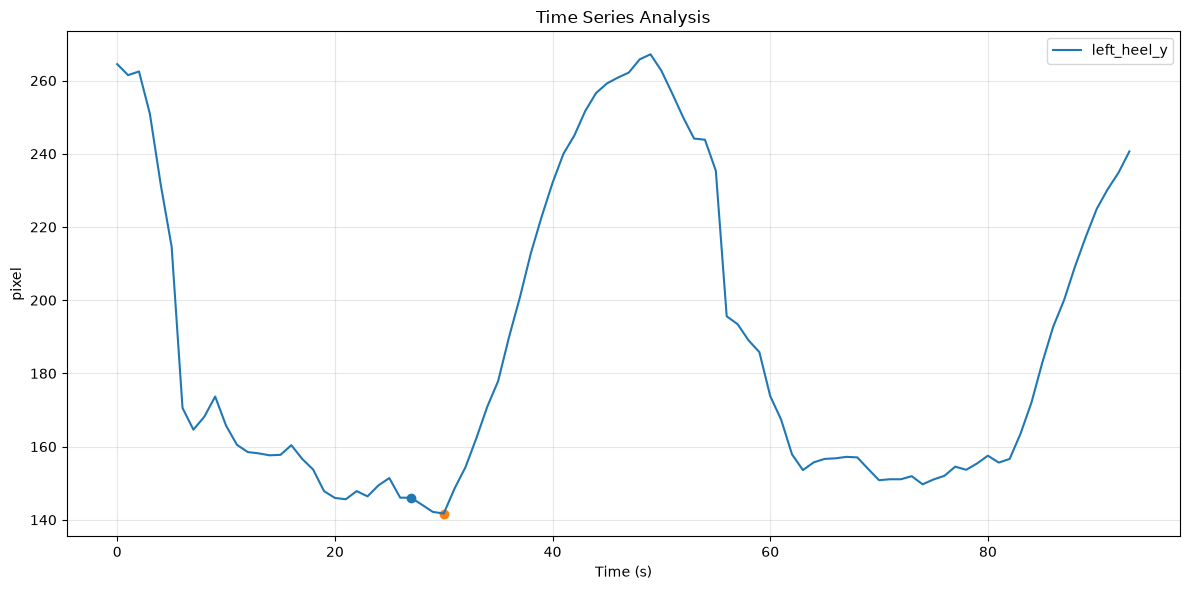

In [3]:
visualize_frame(ps.df[["left_heel_y"]], [27, 30])

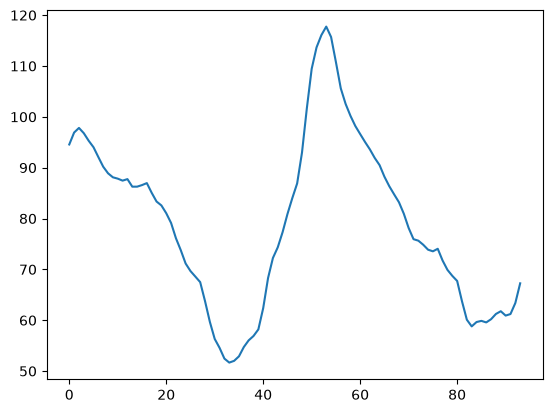

In [4]:
plt.plot(ps.joint_angle("left_elbow", smooth=True))

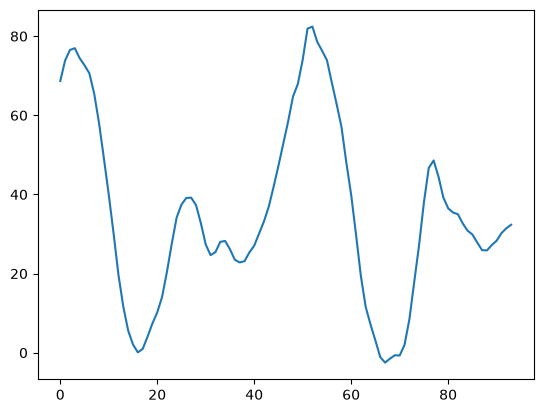

In [5]:
plt.plot(ps.joint_angle("left_knee", smooth=True, negative=True))

In [ ]:
d = "무릎각도"

if d < 50:
    res = {
        'value': d,
        "instruction": "무릎 각도가 너무 낮다. 높여라",
        "outcome": "",

    }
elif d <70:
    res = {
        
    }

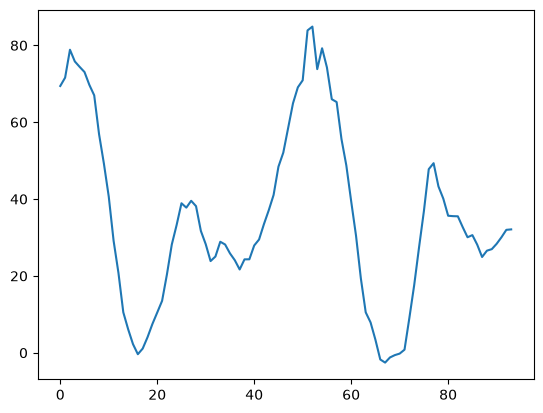

In [6]:
plt.plot(ps.joint_angle(("left_hip", "left_knee", "left_ankle"), negative=True))

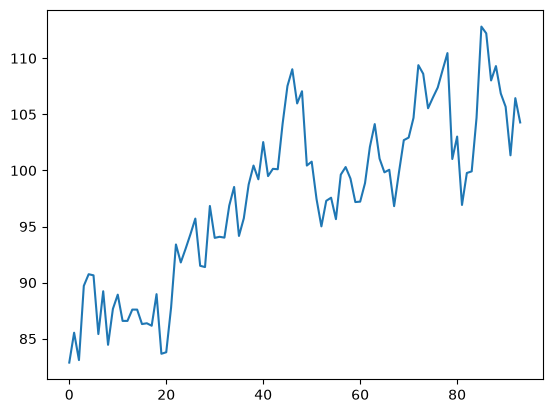

In [7]:
plt.plot(ps.joint_angle(("nose", "left_ear", "neck")))

In [8]:
ps.cal_stride()
ps.pixel2m()

이미 stride가 계산되어 있습니다.
Stride :    frame      value  class
1      3  76.975644      1
4     16   0.091345      0
2     27  39.190298      1
3     37  22.818946      0
1     52  82.430869      1
4     67  -2.495341      0
2     77  48.592180      1
사용자의 키를 기반으로 계산한 픽셀당 meter는 0.0023180223572492106 / pixel 입니다.


In [9]:
ps.cal_stride()

이미 stride가 계산되어 있습니다.
Stride :    frame      value  class
1      3  76.975644      1
4     16   0.091345      0
2     27  39.190298      1
3     37  22.818946      0
1     52  82.430869      1
4     67  -2.495341      0
2     77  48.592180      1
